# Dual Momentum Portfolio Backtest

This notebook implements a dual momentum strategy using moving average crossovers to rotate between stocks, bonds, and cash. The strategy automatically fetches current market data from Yahoo Finance and runs a complete backtest with performance statistics.

**Data Sources:**
- VTI (Vanguard Total Stock Market ETF)
- TLT (iShares 20+ Year Treasury Bond ETF)
- SHY (iShares 1-3 Year Treasury Bond ETF)

**Requirements:**
```bash
pip install yfinance ffn pandas numpy matplotlib
```


## Recent Updates

The notebook has been updated for compatibility with current Python and package versions. Key changes include fixes for pandas 2.x API changes, yfinance parameter updates, and improved error handling. Tested with Python 3.12 and pandas 2.2.3.

---


## Dual Momentum Portfolio Strategy

This notebook implements a simple yet powerful momentum-based asset allocation system that automatically rotates between three asset classes:

### How It Works:
1. **Stock Momentum Test**: If the short-term moving average (10-day) of stock prices is above the long-term moving average (20-day), invest in stocks
2. **Bond Momentum Test**: If stocks fail the momentum test but bonds pass it, invest in bonds
3. **Cash Position**: If both stocks and bonds fail the momentum test, hold cash (short-term treasuries)

This approach aims to:
- Capture uptrends in stocks when momentum is positive
- Preserve capital by rotating to bonds/cash when momentum turns negative
- Reduce maximum drawdown compared to buy-and-hold strategies



## Install Required Packages

If packages are missing, uncomment and run the cell below:

In [44]:
# Uncomment the line below if you need to install packages:
# %pip install yfinance ffn pandas numpy matplotlib numba --quiet


## Import Required Libraries


In [45]:
import datetime
import logging
import os
import sys
import ffn
from collections import OrderedDict
from typing import Dict, List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Try to import numba for performance, but make it optional
try:
    from numba import jit
    HAS_NUMBA = True
except ImportError:
    HAS_NUMBA = False
    # Define a dummy jit decorator if numba is not available
    def jit(*args, **kwargs):
        def decorator(func):
            return func
        return decorator

%matplotlib inline

## Configure Pandas Display Options

Setting pandas options for better output formatting:

In [46]:
pd.set_option("max_colwidth", 100)
pd.set_option("display.max_rows", 100000)
pd.set_option("display.max_columns", 1000)
pd.set_option('display.precision', 6)  # Fixed: use 'display.precision' instead of 'precision'
pd.options.display.float_format = '{:20,.6f}'.format

## Set up Python Logging

Configuring logging for debugging and progress tracking:
- Currently set to: `logging.INFO`
- Set to `DEBUG` if you want verbose output: `logger.setLevel(logging.DEBUG)`

In [47]:
logger = logging.getLogger("a_w")
logger.setLevel(logging.INFO)

# create a file handler
handler = logging.StreamHandler()
for handler in logger.handlers:
    logger.removeHandler(handler)
handler.setLevel(logging.DEBUG)

# create a logging format
formatter = logging.Formatter(
    '%(asctime)s - %(name)s - %(levelname)s - %(message)s')
handler.setFormatter(formatter)

# add the handlers to the logger
logger.addHandler(handler)

## Initialize Strategy Parameters

Configure your backtest settings, tickers, and date ranges:

In [48]:
start: datetime.date = '2000-01-01'  # Start date for backtest
end = datetime.date.today()  # Today's date

starting_capital: float = 100000

# Modern ETF tickers (no need for local files anymore!)
# VTI = Vanguard Total Stock Market ETF (replaces Wilshire TR)
# TLT = iShares 20+ Year Treasury Bond ETF (replaces 30YrBond)
# SHY = iShares 1-3 Year Treasury Bond ETF (replaces 3mTBill)
stock: str = 'VTI'
bond: str = 'TLT'
money: str = 'SHY'

sma_length: int = 10  # Short moving average length
lma_length: int = 20  # Long moving average length

stock_tickers_list: List[str] = [stock, bond, money]

# Output file paths (optional - for saving results)
output_dir = os.path.expanduser("~/Desktop")
test: str = os.path.join(output_dir, "DMtest.csv")
drawdown: str = os.path.join(output_dir, "DMdrawdown.csv")
rebased: str = os.path.join(output_dir, "DMrebased.csv")
stats: str = os.path.join(output_dir, "DMstats.csv")




## Define Calculator Function

This function calculates the equity curve (VAMI - Value Added Monthly Index) by compounding returns day by day:

In [49]:
#This function will calculate the VAMI (Value Added Monthly Index) each day from the return for that day
# Starting with $100, it compounds returns day by day
@jit()
def calculator(a):
    res = np.empty(len(a))
    res[0] = 100
    for i in range(1, len(res)):
        res[i] = res[i-1] + (res[i-1] * a[i])
    return res


## Data Download Function

Fetch current data from Yahoo Finance for the specified tickers:

In [50]:
def download_data(ticker_list: List[str], start_date: str, end_date: datetime.date) -> pd.DataFrame:
    """
    Download data from Yahoo Finance for the given tickers
    :param ticker_list: List of ticker symbols
    :param start_date: Start date for data
    :param end_date: End date for data
    :return: DataFrame with adjusted close prices for all tickers
    """
    logger = logging.getLogger("a_w.download_data")
    logger.info(f"Downloading data for {ticker_list} from {start_date} to {end_date}")
    
    # Download data for all tickers at once
    # Use auto_adjust=False to explicitly get 'Adj Close' column (avoids FutureWarning)
    data = yf.download(ticker_list, start=start_date, end=end_date, progress=False, auto_adjust=False)
    
    # Extract adjusted close prices
    if len(ticker_list) > 1:
        prices = data['Adj Close']
    else:
        prices = data[['Adj Close']]
        prices.columns = ticker_list
    
    # Remove any rows with NaN values
    prices = prices.dropna()
    
    logger.info(f"Downloaded {len(prices)} rows of data")
    return prices

In [51]:
# Test downloading data
test_data = download_data(stock_tickers_list, start, end)
print(f"Data shape: {test_data.shape}")
print(f"Date range: {test_data.index[0]} to {test_data.index[-1]}")
test_data.head()

2025-10-18 20:50:49,279 - a_w.download_data - INFO - Downloading data for ['VTI', 'TLT', 'SHY'] from 2000-01-01 to 2025-10-18
2025-10-18 20:50:49,465 - a_w.download_data - INFO - Downloaded 5844 rows of data


Data shape: (5844, 3)
Date range: 2002-07-30 00:00:00 to 2025-10-17 00:00:00


Ticker,SHY,TLT,VTI
Date,,,
2002-07-30,52.568146,37.055668,27.967033
2002-07-31,52.730324,37.514801,28.032938
2002-08-01,52.834198,37.728470,27.314486
2002-08-02,52.937996,38.114815,26.678429
2002-08-05,53.022373,38.282967,25.788589


## Process and merge data for backtesting
This function will prepare the data with returns and momentum signals:

In [52]:
def prepare_backtest_data(prices: pd.DataFrame, sma_len: int, lma_len: int) -> pd.DataFrame:
    """
    Prepare data for backtesting with returns and momentum signals
    :param prices: DataFrame with price data for stock, bond, money
    :param sma_len: Short moving average length
    :param lma_len: Long moving average length
    :return: DataFrame ready for backtesting
    """
    logger = logging.getLogger("a_w.prepare_backtest_data")
    
    data = prices.copy()
    data.columns = ['stock', 'bond', 'money']
    
    # Calculate returns
    data['stock_return'] = data.stock.pct_change()
    data['bond_return'] = data.bond.pct_change()
    data['money_return'] = data.money.pct_change()
    
    # Calculate momentum signals (MA crossovers)
    data['stock_test'] = data.stock.rolling(sma_len).mean().shift(2) > data.stock.rolling(lma_len).mean().shift(2)
    data['bond_test'] = data.bond.rolling(sma_len).mean().shift(2) > data.bond.rolling(lma_len).mean().shift(2)
    
    # Determine strategy returns based on momentum signals
    conditions = [
        data.stock_test == True,  # Stock momentum positive -> invest in stocks
        (data.stock_test == False) & (data.bond_test == False),  # Both negative -> invest in cash
        data.stock_test == False,  # Stock negative but bond positive -> invest in bonds
    ]
    outputs = [data.stock_return, data.money_return, data.bond_return]
    data['strategy_return'] = np.select(conditions, outputs)
    
    # Drop NaN values
    data.dropna(inplace=True)
    data['equity'] = 0.0
    
    logger.info(f"Prepared backtest data with {len(data)} rows")
    return data[lma_len:]

## Main function to download and prepare data for backtesting:

In [53]:
def get_backtest_data(ticker_list: List[str], start_date: str, end_date: datetime.date,
                      sma_len: int, lma_len: int) -> pd.DataFrame:
    """
    Download data and prepare it for backtesting
    :param ticker_list: List of tickers [stock, bond, money]
    :param start_date: Start date like '2001-01-01' YYYY-MM-DD format
    :param end_date: End date (datetime.date object or string)
    :param sma_len: Short moving average length
    :param lma_len: Long moving average length
    :return: DataFrame ready for backtesting
    """
    logger = logging.getLogger('a_w.get_backtest_data')
    logger.info(f"Getting backtest data for {ticker_list}")
    
    # Download current data from Yahoo Finance
    prices = download_data(ticker_list, start_date, end_date)
    
    # Prepare data with signals and returns
    data = prepare_backtest_data(prices, sma_len, lma_len)
    
    logger.info(f"Backtest data ready with {len(data)} rows")
    return data

## Call the functions listed so far and inspect the dataframe.

In [54]:
data = get_backtest_data(stock_tickers_list, start, end, sma_length, lma_length)

2025-10-18 20:50:49,485 - a_w.get_backtest_data - INFO - Getting backtest data for ['VTI', 'TLT', 'SHY']
2025-10-18 20:50:49,486 - a_w.download_data - INFO - Downloading data for ['VTI', 'TLT', 'SHY'] from 2000-01-01 to 2025-10-18
2025-10-18 20:50:49,587 - a_w.download_data - INFO - Downloaded 5844 rows of data
2025-10-18 20:50:49,593 - a_w.prepare_backtest_data - INFO - Prepared backtest data with 5843 rows
2025-10-18 20:50:49,593 - a_w.get_backtest_data - INFO - Backtest data ready with 5823 rows


In [55]:
inspect_data = pd.DataFrame()
if not data.empty:
    inspect_data = data
    #inspect_data.to_csv("C:\\Users\\agarn\\OneDrive\\Documents\Articles//DM_inspect_data.csv")   
else:
    print('data loading failed see logging')
inspect_data.head()

,stock,bond,money,stock_return,bond_return,money_return,stock_test,bond_test,strategy_return,equity
Date,,,,,,,,,,
2002-08-28,52.879597,39.033009,28.316368,0.000737,0.005033,-0.015920,True,True,0.000737,0.000000
2002-08-29,52.937996,39.346687,28.342760,0.001104,0.008036,0.000932,False,True,0.008036,0.000000
2002-08-30,52.957443,39.583038,28.247156,0.000367,0.006007,-0.003373,False,True,0.006007,0.000000
2002-09-03,53.082924,40.191566,27.146408,0.002369,0.015373,-0.038968,False,True,0.015373,0.000000
2002-09-04,53.063419,40.182446,27.597923,-0.000367,-0.000227,0.016633,False,True,-0.000227,0.000000


In [56]:
# Calculate the equity curve using the calculator function
data['equity'] = calculator(data['strategy_return'].values)
data.head()

,stock,bond,money,stock_return,bond_return,money_return,stock_test,bond_test,strategy_return,equity
Date,,,,,,,,,,
2002-08-28,52.879597,39.033009,28.316368,0.000737,0.005033,-0.015920,True,True,0.000737,100.000000
2002-08-29,52.937996,39.346687,28.342760,0.001104,0.008036,0.000932,False,True,0.008036,100.803624
2002-08-30,52.957443,39.583038,28.247156,0.000367,0.006007,-0.003373,False,True,0.006007,101.409140
2002-09-03,53.082924,40.191566,27.146408,0.002369,0.015373,-0.038968,False,True,0.015373,102.968149
2002-09-04,53.063419,40.182446,27.597923,-0.000367,-0.000227,0.016633,False,True,-0.000227,102.944782


## Inspect the Downloaded Data

View the first few rows of the prepared dataset:


## Save backtest data to file for further inspection. Use FFN package to create charts and statistics for the backtest.

## Calculate Equity Curve

Apply the calculator function to generate the strategy's equity curve:


In [57]:
def show_stats(backtest: pd.DataFrame):
    if backtest is not None and not backtest.empty:
        logger = logging.getLogger('a_w.charts')
        res = backtest.equity.astype(np.float64)
        benchmarked = pd.concat(
            [res, backtest.stock, backtest.bond], sort=False, axis=1)
        
        # Print data date range
        print(f"Backtest Period: {backtest.index[0].strftime('%Y-%m-%d')} to {backtest.index[-1].strftime('%Y-%m-%d')}")
        print(f"Total Trading Days: {len(backtest)}")
        print("\n" + "="*60 + "\n")
        
        log = True
        benchmarked.rebase().plot(figsize=(10, 7), logy=log, title='Dual Momentum Strategy vs Buy & Hold')
        plt.ylabel('Value of $100 Invested (log scale)')
        plt.xlabel('Date')
        plt.legend(['Dual Momentum Strategy', 'Stock (VTI)', 'Bond (TLT)'])
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        benchmarked.calc_stats().display()
        
        benchmarked.to_drawdown_series().plot(figsize=(10, 6), title='Drawdown Analysis')
        plt.ylabel('Drawdown (%)')
        plt.xlabel('Date')
        plt.legend(['Dual Momentum Strategy', 'Stock (VTI)', 'Bond (TLT)'])
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Save files
        def save_1(): backtest.to_csv(test)
        def save_2(): benchmarked.rebase().to_csv(rebased)
        def save_3(): benchmarked.calc_stats().to_csv(sep=', ', path=stats)
        def save_4(): benchmarked.to_drawdown_series().to_csv(drawdown)
        
        save_files = [save_1, save_2, save_3, save_4]
        save_names = ['backtest', 'rebased', 'stats', 'drawdown']
        
        for s, name in zip(save_files, save_names):
            try:
                s()
                logger.info(f'Saved {name} successfully')
            except Exception as e:
                logger.warning(f'Could not save {name}: {e}')
                continue

    else:
        print('backtest failed see logging')

## Call the show-backtest function

Backtest Period: 2002-08-28 to 2025-10-17
Total Trading Days: 5823




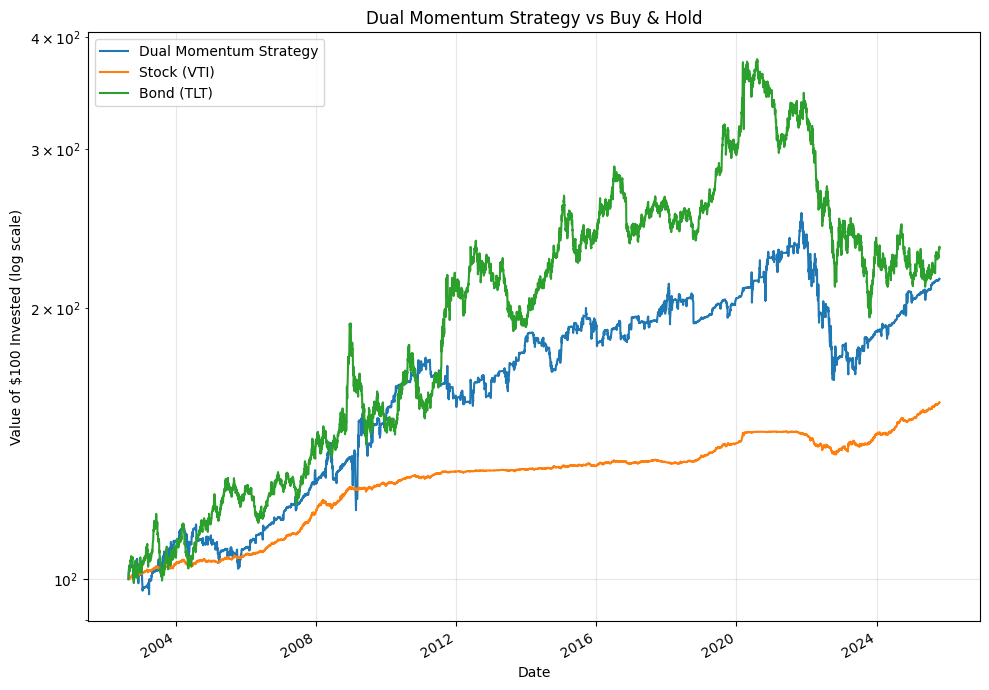

Stat                 equity      stock       bond
-------------------  ----------  ----------  ----------
Start                2002-08-28  2002-08-28  2002-08-28
End                  2025-10-17  2025-10-17  2025-10-17
Risk-free rate       0.00%       0.00%       0.00%

Total Return         115.56%     57.13%      133.65%
Daily Sharpe         0.40        1.29        0.33
Daily Sortino        0.58        2.23        0.55
CAGR                 3.38%       1.97%       3.74%
Max Drawdown         -34.74%     -5.71%      -48.35%
Calmar Ratio         0.10        0.35        0.08

MTD                  0.47%       0.47%       2.40%
3m                   2.77%       1.72%       8.35%
6m                   3.47%       2.35%       6.53%
YTD                  6.11%       4.32%       7.88%
1Y                   7.34%       4.69%       1.52%
3Y (ann.)            8.02%       4.44%       1.39%
5Y (ann.)            0.19%       1.52%       -8.04%
10Y (ann.)           1.01%       1.58%       -0.38%
Since Incep.

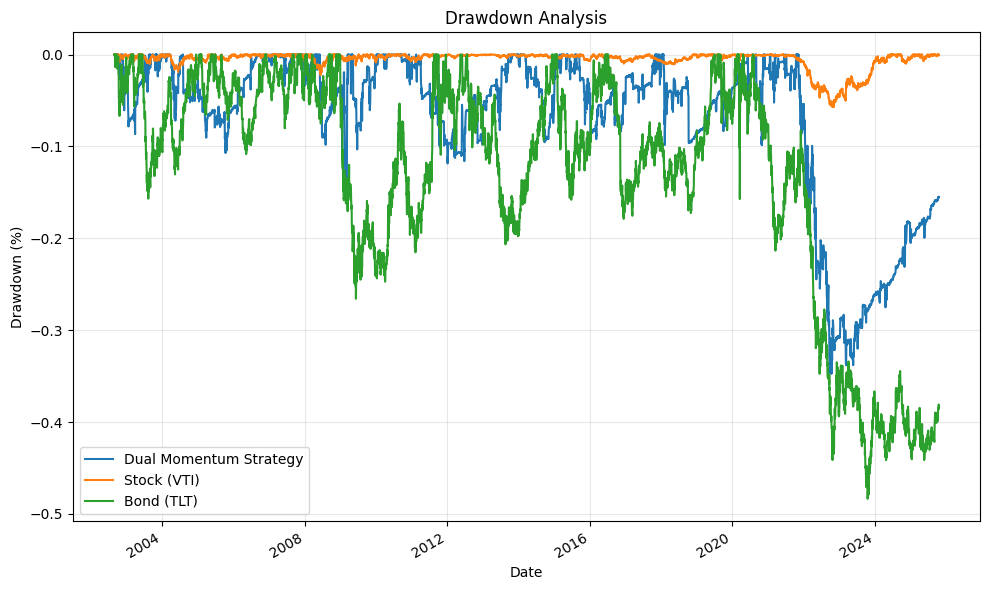

2025-10-18 20:50:50,374 - a_w.charts - INFO - Saved backtest successfully
2025-10-18 20:50:50,401 - a_w.charts - INFO - Saved rebased successfully
2025-10-18 20:50:50,461 - a_w.charts - INFO - Saved stats successfully
2025-10-18 20:50:50,484 - a_w.charts - INFO - Saved drawdown successfully


In [58]:
show_stats(data)

## Current Strategy Allocation

Check what the strategy would be invested in today:

In [ ]:
# Check current allocation
if not data.empty:
    latest = data.iloc[-1]
    latest_date = data.index[-1].strftime('%Y-%m-%d')
    
    print(f"Strategy Status as of {latest_date}")
    print("="*50)
    
    if latest['stock_test']:
        allocation = "STOCKS (VTI)"
        reason = "Stock momentum is positive"
    elif latest['bond_test']:
        allocation = "BONDS (TLT)"
        reason = "Stock momentum is negative, but bond momentum is positive"
    else:
        allocation = "CASH (SHY)"
        reason = "Both stock and bond momentum are negative"
    
    print(f"\nCurrent Allocation: {allocation}")
    print(f"Reason: {reason}")
    print(f"\nLast 5 trading days:")
    recent = data[['stock_test', 'bond_test', 'strategy_return']].tail().copy()
    
    # Set allocation based on test results (use proper boolean indexing)
    recent['allocation'] = 'CASH'  # Default to cash
    recent.loc[recent['stock_test'] == True, 'allocation'] = 'STOCK'
    recent.loc[(recent['stock_test'] == False) & (recent['bond_test'] == True), 'allocation'] = 'BOND'
    
    print(recent[['allocation', 'strategy_return']])


📊 Strategy Status as of 2025-10-17

Current Allocation: 🟢 STOCKS (VTI)
Reason: Stock momentum is positive

Last 5 signals:
           allocation      strategy_return
Date                                      
2025-10-13      STOCK             0.001929
2025-10-14      STOCK            -0.000722
2025-10-15      STOCK            -0.000482
2025-10-16      STOCK             0.001325
2025-10-17      STOCK            -0.000120


## Package Version Information

Check installed package versions:


In [ ]:
from platform import python_version
import pkg_resources

print("Python Version:", python_version())
print("\nKey Package Versions:")
print("-" * 40)

packages = ['numpy', 'pandas', 'matplotlib', 'yfinance', 'ffn', 'numba']
for package in packages:
    try:
        version = pkg_resources.get_distribution(package).version
        print(f"{package:15} {version}")
    except:
        print(f"{package:15} NOT INSTALLED")


Python Version: 3.12.1

Key Package Versions:
----------------------------------------
numpy           2.2.1
pandas          2.2.3
matplotlib      3.10.7
yfinance        0.2.66
ffn             1.1.2
numba           0.62.1


## System Information

Display Python and system details:

In [61]:
# Display system information
print(f"Python {sys.version}")
print(f"\nSystem: {sys.platform}")
print(f"Version Info: {sys.version_info}")


Python 3.12.1 | packaged by Anaconda, Inc. | (main, Jan 19 2024, 09:45:58) [Clang 14.0.6 ]

System: darwin
Version Info: sys.version_info(major=3, minor=12, micro=1, releaselevel='final', serial=0)
